In [382]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

In [383]:
# Load and prepare data
folder_path="F:/Computer Science/Data Mining/Traffic count Project"

all_files=glob.glob(os.path.join(folder_path,"Emperial*.csv"))
df_list=[pd.read_csv(file) for file in all_files]
combined_df=pd.concat(df_list, ignore_index=True)
combined_df.to_csv("merged.csv", index=False)

# Load merged data inot dataframe
df=pd.read_csv("merged.csv")

In [384]:
print("Shape:",df.shape)
print(df.info())

Shape: (30206, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30206 entries, 0 to 30205
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   type        30206 non-null  object 
 1   latitude    30206 non-null  float64
 2   longitude   30206 non-null  float64
 3   time        30206 non-null  object 
 4   date        30206 non-null  object 
 5   from        30206 non-null  object 
 6   to          30206 non-null  object 
 7   # of Lane   30206 non-null  int64  
 8   on the day  30206 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 2.1+ MB
None


In [385]:
# Every row = 1 vehicle observation
df["vehicle_count"] = 1
df.sample(2)

,type,latitude,longitude,time,date,from,to,# of Lane,on the day,vehicle_count
4360,Automobile,9.015965,38.803167,8:20:33 AM,6/2/2026,Emperial,Megenagna,7,SB,1
7065,Dump Truck,9.015965,38.803167,9:47:55 AM,6/2/2026,Emperial,Megenagna,7,SB,1


In [386]:
# convert into panda date format (datetime object)
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])
df=df.sort_values("datetime")

In [387]:
# Create time-of-day groups
def get_period(hour):
    if 6 <= hour < 10:
        return "morning"
    elif 10 <= hour < 14:
        return "midday"
    else:
        return "evening"

In [388]:
# Assign period BEFORE grouping
df["period"]=df["datetime"].dt.hour.apply(get_period)

In [389]:
# Group properly since we have multiple days

df["date"] = df["datetime"].dt.date

survey_period = df.groupby(["date", "period"]).agg(total_flow=("vehicle_count", "sum"),
    start_time=("datetime", "min"),
    end_time=("datetime", "max")
).reset_index()
survey_period.head(3)

,date,period,total_flow,start_time,end_time
0,2026-05-18,morning,428,2026-05-18 09:26:54,2026-05-18 09:38:39
1,2026-05-24,evening,1153,2026-05-24 17:50:13,2026-05-24 18:35:18
2,2026-05-25,evening,1903,2026-05-25 17:45:54,2026-05-25 18:41:17


In [390]:
# we have unequal observation duration. A 30-min- 3-hour survey. we standardize to make them comparable.
#B/c our total_flow is still raw count. 5414 (2hrs) will look “busier” than 428 (12 min), even if real traffic rate is similar.
# The correct fix: --> convert everything to a rate. You should NOT compare totals directly.
# You should compute: -->  Vehicle flow rate (recommended)

survey_period["duration_hours"] = (pd.to_datetime(survey_period["end_time"]) -
                                   pd.to_datetime(survey_period["start_time"])).dt.total_seconds()/3600

survey_period

,date,period,total_flow,start_time,end_time,duration_hours
0,2026-05-18,morning,428,2026-05-18 09:26:54,2026-05-18 09:38:39,0.195833
1,2026-05-24,evening,1153,2026-05-24 17:50:13,2026-05-24 18:35:18,0.751389
2,2026-05-25,evening,1903,2026-05-25 17:45:54,2026-05-25 18:41:17,0.923056
3,2026-05-28,midday,1700,2026-05-28 12:38:08,2026-05-28 13:32:24,0.904444
4,2026-05-30,evening,1063,2026-05-30 16:52:03,2026-05-30 17:25:23,0.555556
5,2026-05-31,midday,502,2026-05-31 10:00:01,2026-05-31 10:25:54,0.431389
6,2026-05-31,morning,1581,2026-05-31 08:24:00,2026-05-31 09:59:59,1.599722
7,2026-06-01,morning,864,2026-06-01 07:54:55,2026-06-01 09:56:27,2.025556
8,2026-06-02,midday,3,2026-06-02 10:00:02,2026-06-02 10:00:11,0.002500
9,2026-06-02,morning,5414,2026-06-02 06:58:15,2026-06-02 09:59:58,3.028611


In [391]:
# Compute normalized flow, data becomes comparable.
survey_period["flow_per_hour"] = survey_period["total_flow"] / survey_period["duration_hours"]

# Fix inf (invalid value)
survey_period = survey_period.replace([float("inf"), -float("inf")], pd.NA)
survey_period = survey_period.dropna(subset=["flow_per_hour"])
survey_period = survey_period[survey_period["flow_per_hour"] > 0]

In [392]:
# Aggregate correctly by period, instead of summing raw flow: weighted mean rate. good traffic engineering method. 
result = survey_period.groupby("period").apply(
    lambda x: x["total_flow"].sum() / x["duration_hours"].sum()
).reset_index(name="vehicles_per_hour")
result

,period,vehicles_per_hour
0,evening,1674.595198
1,midday,1647.571606
2,morning,1450.506553


In [393]:
"""Why weighted is better than simple mean. If you do: df.groupby("period")["flow_per_hour"].mean()
that treats: 12-minute survey = same importance as 3-hour survey
But weighted version: longer surveys contribute more influence """

'Why weighted is better than simple mean. If you do: df.groupby("period")["flow_per_hour"].mean()\nthat treats: 12-minute survey = same importance as 3-hour survey\nBut weighted version: longer surveys contribute more influence '

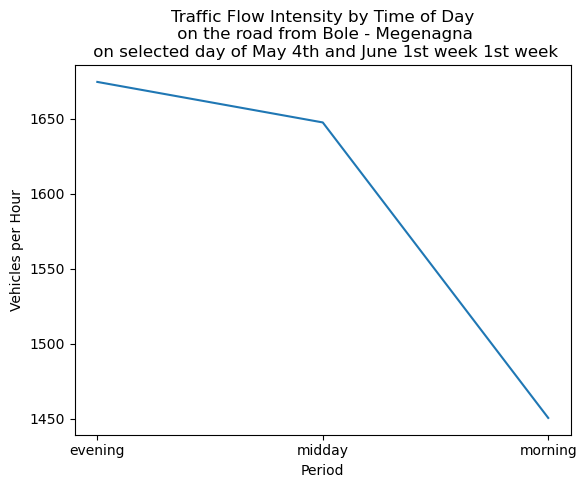

In [401]:
# Plot results of traffic flow intensity
plt.plot(result["period"], result["vehicles_per_hour"])
plt.title("Traffic Flow Intensity by Time of Day\n on the road from Bole - Megenagna" 
          "\n on selected day of May 4th and June 1st week 1st week")
plt.xlabel("Period")
plt.ylabel("Vehicles per Hour")
plt.savefig("traffic_flow_intensity.png", dpi=300, bbox_inches="tight")
plt.show()

In [395]:
# Classify vehicles inti different transportation mode

pub_bus = ["Anbessa Bus", "Sheger Bus", 'Public Service', 'Anbessa Double Bus','Private City Bus','Anbessa Double Bus']
other_bus =['City Support Bus', 'Midibus' ]
minibus =['Vantransport', 'Minibus Taxi']

bicyle =['Motorcycle','Bicycle']
automobile = ["Automobile",'D Taxi','Airport Taxi']
service_veh=['Tipper', 'Ambulance','Machine', 'Truck Remorque', 'Dump Truck','Mixer Truck','SUV', 'Pickup']

df["transport_mode"] = "others"

df.loc[df["type"].isin(pub_bus), "transport_mode"] = "pub_bus"
df.loc[df["type"].isin(other_buses), "transport_mode"] = "other_bus"
df.loc[df["type"].isin(minibus), "transport_mode"] = "minibus"

df.loc[df["type"].isin(automobile), "transport_mode"] = "Automobile"
df.loc[df["type"].isin(service_vehicle), "transport_mode"] = "service_veh"
df.loc[df["type"].isin(bicyle), "transport_mode"] = "bicycle"

df.sample(1)

,type,latitude,longitude,time,date,from,to,# of Lane,on the day,vehicle_count,datetime,period,transport_mode
7983,Automobile,9.015965,38.803167,4:42:25 PM,2026-06-03,Emperial,Megenagna,7,SB,1,2026-06-03 16:42:25,evening,Automobile


In [396]:
# Group based on transport mode
summary = (
    df.groupby("transport_mode")["vehicle_count"]
      .sum()
      .reset_index()
)
summary=summary.sort_values("vehicle_count")
summary

,transport_mode,vehicle_count
3,other_bus,568
1,bicycle,704
4,others,844
5,pub_bus,1650
6,service_veh,4775
2,minibus,5014
0,Automobile,16651


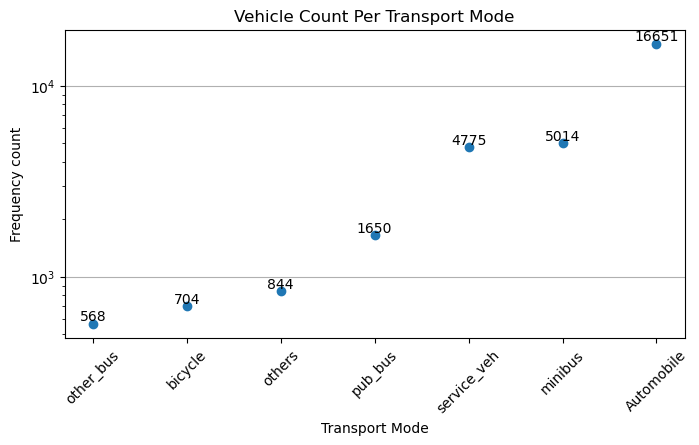

In [402]:
# Show transport mode using graph
plt.figure(figsize=(8,4))
for i, value in enumerate(summary["vehicle_count"]):
    plt.text(i, value, str(int(value)), ha="center", va="bottom"
    )
plt.plot(summary["transport_mode"], summary["vehicle_count"], marker="o", linestyle="None")
plt.title("Vehicle Count Per Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Frequency count")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.savefig("Vehicle_count_per_transport_mode.png", dpi=300, bbox_inches="tight")
plt.yscale("log") #This (log scale) makes smaller categories visible.
plt.show()

In [398]:
# Estimated passenger per transport mode
occupancy = {"Automobile": 1.7, "minibus": 15, "pub_bus": 90, "service_veh": 1.5, "bicycle": 1, "other_bus": 50, "others": 1.2}

# Estimate passengers
summary["occupancy"]=summary["transport_mode"].map(occupancy)
summary["estimated_passengers"]=summary["vehicle_count"]*summary["occupancy"]

In [399]:
summary

,transport_mode,vehicle_count,occupancy,estimated_passengers
3,other_bus,568,50.0,28400.0
1,bicycle,704,1.0,704.0
4,others,844,1.2,1012.8
5,pub_bus,1650,90.0,148500.0
6,service_veh,4775,1.5,7162.5
2,minibus,5014,15.0,75210.0
0,Automobile,16651,1.7,28306.7


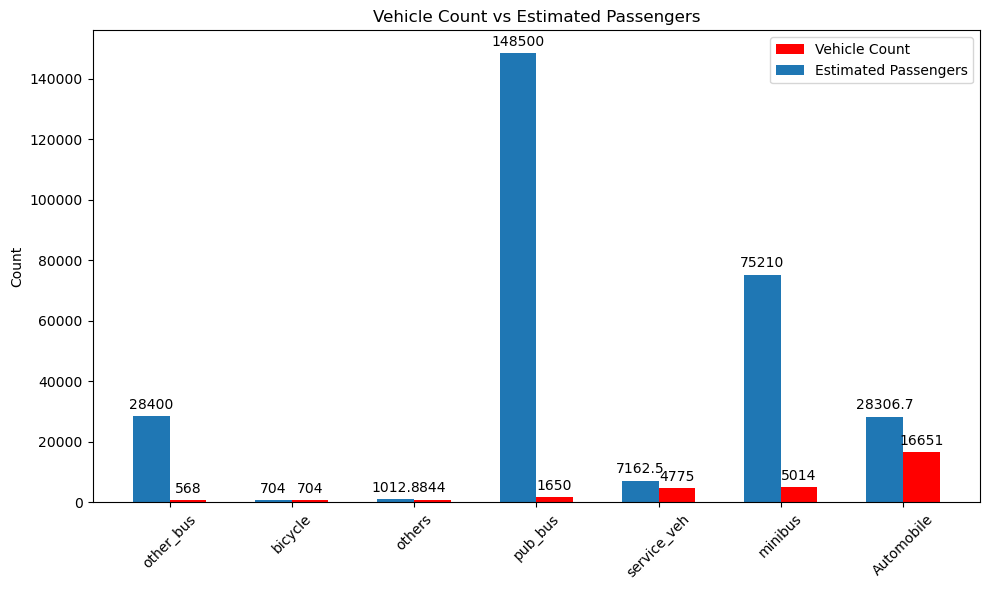

In [404]:
# Which transport mode serves more passengers?
x=np.arange(len(summary))# Array
width=0.3
fig, ax=plt.subplots(figsize=(10,6))
bar1=ax.bar(x +width/2, summary["vehicle_count"],width, label="Vehicle Count", color="r")
bar2=ax.bar(x-width/2, summary["estimated_passengers"],width, label="Estimated Passengers")

ax.set_xticks(x)
ax.set_xticklabels(summary["transport_mode"], rotation=45)
ax.set_ylabel("Count")
ax.set_title("Vehicle Count vs Estimated Passengers")

# Show values on bars
ax.bar_label(bar1, padding=3)
ax.bar_label(bar2, padding=3)
ax.legend()
plt.savefig("Vehicle Count vs Estimated Passengers.png", dpi=200, bbox_inches="tight")

plt.tight_layout()
plt.show()